# 02_Data_cleaning

**Objectif** : transformer les données brutes en un dataset propre et exploitable.

**Objectif final** : développer un modèle capable de prédire la gravité d'un accident en fonction de ses circonstances (lieu, heure, conditions atmosphériques, type de route).

Après lecture de la documentation et des différentes variables, on peut dire que notre variable à prédire sera la variable : `grav` dans la table `USAGERS`. Cette variable est définie comme suit dans la documentation : "Gravité de blessure de l'usager, les usagers accidentés sont classés en trois catégories de victimes + les indemnes."

Cette variable a 4 valeurs possibles :

1 – Indemne  
2 – Tué  
3 – Blessé hospitalisé  
4 – Blessé léger  

Dans ce notebook nous allons donc produire un dataset au niveau accident :
- 1 ligne = 1 accident
- Variables explicatives = circonstances de l’accident (lieu, heure, environnement)
- Variable cible = gravité de l’accident, dérivée de `grav` (`USAGERS`)
- Dataset propre, cohérent, interprétable, prêt pour EDA et feature engineering

## Import des librairies et des données

In [2]:
import pandas as pd
from pathlib import Path
import missingno as msno
import matplotlib.pyplot as plt

Au tout début, on charge toutes les colonnes en texte (str) pour éviter les erreurs de conversion (ex : virgules décimales, espaces insécables, codes “-1”, formats mixtes).  
Ensuite seulement, on convertira colonne par colonne en numérique/datetime quand on a compris les valeurs possibles.

In [3]:
# Chemin vers le dossier raw
data_raw_path = Path("../data/raw")

# Dictionnaire pour stocker tous les DataFrames
dataframes = {}

# Boucle sur tous les fichiers CSV dans tous les sous-dossiers
for csv_file in data_raw_path.rglob("*.csv"):
    
    # Récupère le nom du fichier sans extension
    file_stem = csv_file.stem
    
    # Crée un nom unique pour le DataFrame
    df_name = f"df_{file_stem.replace('-', '_')}"
    
    # Lecture du CSV en string pour la découverte
    df = pd.read_csv(csv_file, sep=";", dtype=str)
    
    # Stocke le DataFrame dans le dictionnaire
    dataframes[df_name] = df

# Affichage pour vérifier que tout est importé
print("DataFrames importés :", list(dataframes.keys()))

DataFrames importés : ['df_caract_2022', 'df_lieux_2022', 'df_usagers_2022', 'df_caract_2023', 'df_lieux_2023', 'df_usagers_2023', 'df_caract_2024', 'df_lieux_2024', 'df_usagers_2024']


In [4]:
# Crée des variables DataFrame à partir du dictionnaire
for name, df in dataframes.items():
    globals()[name] = df

## Harmonisation et préparation des tables brutes

## Harmonisation des noms de colonnes

In [5]:
for name, df in dataframes.items():
    print(f"DATAFRAME : {name}")
    display(df.columns)

DATAFRAME : df_caract_2022


Index(['Accident_Id', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')

DATAFRAME : df_lieux_2022


Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')

DATAFRAME : df_usagers_2022


...

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long'],
      dtype='str')

DATAFRAME : df_lieux_2024


Index(['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof',
       'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ',
       'vma'],
      dtype='str')

DATAFRAME : df_usagers_2024


Index(['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu',
       'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'actp', 'etatp'],
      dtype='str')

In [6]:
# Renommer la colonne Accident_Id en Num_Acc dans df_caract_2022
df_caract_2022.rename(columns={"Accident_Id" : "Num_Acc"},inplace=True)
df_caract_2022.head()

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"


### Concaténation par table

In [7]:
# Tables caract
df_caract = pd.concat([df_caract_2022, df_caract_2023, df_caract_2024], ignore_index=True)  
df_caract

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202400054398,10,07,2024,02:05,5,94,94065,2,3,2,6,Avenue Charles Lindbergh,"48,75740000","2,34469000"
164522,202400054399,30,11,2024,15:27,1,92,92062,2,1,1,6,RUE PIERRE GAUDIN,"48,88694322","2,24863619"
164523,202400054400,24,10,2024,20:40,3,29,29068,1,1,1,1,PK 031.950 RN12,"48,52619024","-3,96317650"
164524,202400054401,30,11,2024,15:40,1,92,92012,2,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,"48,83286197","2,24394009"


In [8]:
# Vérification des dimensions
df_caract.shape == (
    df_caract_2022.shape[0]
    + df_caract_2023.shape[0]
    + df_caract_2024.shape[0], # somme des lignes
    df_caract_2022.shape[1] # colonnes
)

True

In [9]:
# Tables usagers
df_usagers = pd.concat([df_usagers_2022, df_usagers_2023, df_usagers_2024], ignore_index=True)
df_usagers

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202200000001,1 099 700,813 952,A01,1,1,3,1,2008,5,2,8,-1,-1,-1,-1
1,202200000001,1 099 701,813 953,B01,1,1,1,1,1948,5,1,8,-1,-1,-1,-1
2,202200000002,1 099 698,813 950,B01,1,1,4,1,1988,9,1,0,-1,0,0,-1
3,202200000002,1 099 699,813 951,A01,1,1,1,1,1970,4,1,0,-1,0,0,-1
4,202200000003,1 099 696,813 948,A01,1,1,1,1,2002,0,1,0,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,203 859 570,155 686 119,Y01,1,1,4,2,1978,0,0,0,0,-1,-1,-1
377634,202400054401,203 859 572,155 686 120,A01,1,1,1,1,1984,0,2,6,0,-1,-1,-1
377635,202400054402,203 859 569,155 686 118,A01,1,1,4,1,1981,4,1,0,-1,-1,-1,-1
377636,202400054402,203 859 571,155 686 121,B01,1,1,4,2,1986,9,1,0,-1,-1,-1,-1


In [10]:
# Vérification des dimensions
df_usagers.shape == (
    df_usagers_2022.shape[0]
    + df_usagers_2023.shape[0]
    + df_usagers_2024.shape[0],
    df_usagers_2022.shape[1] 
)

True

In [11]:
# Tables lieux
df_lieux = pd.concat([df_lieux_2022, df_lieux_2023, df_lieux_2024], ignore_index=True)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50
1,202200000002,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50
2,202200000003,3,ROND POINT DE BREZILLET,0,NaN,-1,2,0,1,0,0,1,NaN,-1,1,5,1,50
3,202200000004,4,QUATORZE JUILLET (RUE DU),0,NaN,1,1,0,2,(1),(1),1,NaN,4,1,0,1,30
4,202200000005,3,ROUTE DE JEAN MOULIN-RN 538,0,NaN,2,2,0,1,8,0,1,NaN,-1,1,0,1,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
196406,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
196407,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
196408,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [12]:
# Vérification des dimensions
df_lieux.shape == (
    df_lieux_2022.shape[0]
    + df_lieux_2023.shape[0]
    + df_lieux_2024.shape[0],
    df_lieux_2022.shape[1]
)

True

## Création de df copies

On travaille sur des copies (df_*_cleaning) pour garder les DataFrames bruts intacts.
Ça permet de revenir en arrière facilement et de comparer “avant / après” si on repère une erreur.

In [13]:
df_caract_cleaning = df_caract.copy()

In [14]:
df_lieux_cleaning = df_lieux.copy()

In [15]:
df_usagers_cleaning = df_usagers.copy()

## Vérifier si `Num_Acc` est unique dans `CARACTERISTIQUES` et s'il y a le même nombre dans `USAGERS` et `LIEUX`

In [16]:
# Unicité dans CARACT
df_caract_cleaning["Num_Acc"].is_unique

True

In [17]:
# Nombre de lignes par accident (USAGERS)
df_usagers_cleaning["Num_Acc"].value_counts().describe()

count    164526.000000
mean          2.295309
std           1.267326
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          65.000000
Name: count, dtype: float64

In [18]:
# Nombre de lignes par accident (LIEUX)
df_lieux_cleaning["Num_Acc"].value_counts().describe()

count    164526.000000
mean          1.193793
std           0.401419
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           5.000000
Name: count, dtype: float64

## Exploration des valeurs possibles

### Table `CARACTERISTIQUES`

Avant de nettoyer, on explore les valeurs présentes dans chaque colonne pour repérer :
- valeurs spéciales (-1)
- formats inattendus
- colonnes “très textuelles” (adresse)

In [19]:
for col in df_caract_cleaning.columns:
    print("=" * 80)
    print(f"Colonne : {col}")
    display(
        df_caract_cleaning[col]
        .astype("string")
        .value_counts(dropna=False)
        .head(15)
    )

Colonne : Num_Acc


Num_Acc
202200000001    1
202200000002    1
202200000003    1
202200000004    1
202200000005    1
202200000006    1
202200000007    1
202200000008    1
202200000009    1
202200000010    1
202200000011    1
202200000012    1
202200000013    1
202200000014    1
202200000015    1
Name: count, dtype: Int64

Colonne : jour


jour
7     5731
13    5637
14    5632
8     5629
11    5607
6     5595
9     5585
5     5569
12    5567
10    5564
16    5552
21    5531
4     5519
3     5423
19    5391
Name: count, dtype: Int64

Colonne : mois


...

adr
<NA>                           4932
A86                             910
A4                              736
A13                             661
AUTOROUTE A1                    600
AUTOROUTE A86                   595
AUTOROUTE A6                    568
RN 104                          499
AUTOROUTE A3                    499
BD PERIPHERIQUE INTERIEUR       423
A15                             408
BD PERIPHERIQUE EXTERIEUR       394
ROCADE A 630                    264
A7-Sens Marseille vers Lyon     245
A1                              230
Name: count, dtype: Int64

Colonne : lat


lat
48,93788866      17
 -17,61800000    17
 -17,58400000    17
48,91936344      13
 -17,57700000    12
 -17,75600000    12
48,94355783      12
48,8172046066    11
48,83020089      11
48,96300436      11
48,89707199      11
48,94364712      10
 -17,59200000    10
48,93542176      10
 -16,38800000     9
Name: count, dtype: Int64

Colonne : long


long
 -149,56000000    19
2,29766722        17
 -149,54900000    17
2,35754643        13
 -150,20200000    12
 -148,73600000    12
5,40000000        12
2,28738079        12
2,4285178250      11
2,49576700        11
2,52239723        11
2,46965129        11
2,28775617        10
 -149,39100000    10
2,26058310        10
Name: count, dtype: Int64

### Table `LIEUX`

Avant de nettoyer, on explore pour repérer :
- -1 parfois en string " -1" (avec espaces)
- valeurs comme "(1)" dans pr et pr1
- virgules décimales dans larrout (ex "10,5")
- la valeur spéciale #VALEURMULTI dans nbv

In [20]:
for col in df_lieux_cleaning.columns:
    print("=" * 80)
    print(f"Colonne : {col}")
    display(
        df_lieux_cleaning[col]
        .astype("string")
        .value_counts(dropna=False)
        .head(15)
    )

Colonne : Num_Acc


Num_Acc
202300035508    5
202400050330    5
202300006227    4
202300007795    4
202300011843    4
202300015235    4
202300016172    4
202300034748    4
202300036543    4
202300039940    4
202300046485    4
202300053680    4
202300054010    4
202400005122    4
202400005927    4
Name: count, dtype: Int64

Colonne : catr


catr
4    87012
3    74346
1    15446
2    11567
7     5883
6     1248
9      718
5      190
Name: count, dtype: Int64

Colonne : voie


...

infra
0      163660
5       12498
9        6690
2        3063
 -1      2429
3        2158
1        1971
6        1894
8        1357
4         578
7         112
Name: count, dtype: Int64

Colonne : situ


situ
1      163493
3       12256
8        7556
5        5142
4        4245
6        2459
2        1016
 -1       243
Name: count, dtype: Int64

Colonne : vma


vma
50     89139
30     35752
80     24168
90     14576
70     12527
 -1     9105
110     5744
130     3216
20       697
60       356
10       319
40       221
25       171
15       106
5         77
Name: count, dtype: Int64

### Table `USAGERS`

Avant de nettoyer, on explore pour repérer :
- les codes de `grav`
- les -1 / valeurs manquantes
- colonnes d’identifiants (beaucoup de valeurs uniques)

In [21]:
for col in df_usagers_cleaning.columns:
    print("=" * 80)
    print(f"Colonne : {col}")
    display(
        df_usagers_cleaning[col]
        .astype("string")
        .value_counts(dropna=False)
        .head(15)
    )

Colonne : Num_Acc


Num_Acc
202300043857    65
202400034184    56
202300008814    54
202400033079    51
202400053213    50
202400024077    49
202400041600    48
202400015934    47
202400008071    43
202300021103    41
202200032758    39
202400013932    39
202200019645    38
202200041415    36
202300017107    36
Name: count, dtype: Int64

Colonne : id_usager


id_usager
1 099 700    1
1 099 701    1
1 099 698    1
1 099 699    1
1 099 696    1
1 099 697    1
1 099 694    1
1 099 695    1
1 099 692    1
1 099 693    1
1 099 690    1
1 099 691    1
1 099 685    1
1 099 686    1
1 099 687    1
Name: count, dtype: Int64

Colonne : id_vehicule


...

locp
 -1    176193
0      171618
3        9695
2        6030
4        4456
1        4276
5        2429
9        1505
6         964
8         447
7          25
Name: count, dtype: Int64

Colonne : actp


actp
 -1    174583
0      173205
3       21989
9        2026
1        1953
B        1036
5        1020
2         977
A         368
4         305
6          73
7          68
8          35
Name: count, dtype: Int64

Colonne : etatp


etatp
 -1    347811
1       22751
2        5925
3        1151
Name: count, dtype: Int64

## Nettoyage des tables

### Table `CARACTERISTIQUES`

Rôle : base principale du dataset final (1 ligne = 1 accident)

#### Conversion des types de données

In [22]:
df_caract_cleaning.dtypes

Num_Acc    str
jour       str
mois       str
an         str
hrmn       str
lum        str
dep        str
com        str
agg        str
int        str
atm        str
col        str
adr        str
lat        str
long       str
dtype: object

In [23]:
# Coordonnées GPS en float
df_caract_cleaning["lat"] = df_caract_cleaning["lat"].astype("string").str.replace(",", ".", regex=False)

In [24]:
df_caract_cleaning["long"] = df_caract_cleaning["long"].astype("string").str.replace(",", ".", regex=False)

In [25]:
df_caract_cleaning["lat"] = pd.to_numeric(df_caract_cleaning["lat"], errors="coerce")

In [26]:
df_caract_cleaning["long"] = pd.to_numeric(df_caract_cleaning["long"], errors="coerce")

In [27]:
# Conversion en variables numériques 
for col in ["jour", "mois", "an", "lum", "agg", "int", "atm", "col"]:
    df_caract_cleaning[col] = pd.to_numeric(df_caract_cleaning[col], errors="coerce")

In [28]:
# Nettoyer la variable adr
df_caract_cleaning["adr"] = (
    df_caract_cleaning["adr"].astype("string").replace({"<NA>": pd.NA, "": pd.NA})
)

In [29]:
# Création de la variable datetime
df_caract_cleaning["date_hrmn"] = pd.to_datetime(
    df_caract_cleaning["an"].astype("Int64").astype("string") + "-" +
    df_caract_cleaning["mois"].astype("Int64").astype("string").str.zfill(2) + "-" +
    df_caract_cleaning["jour"].astype("Int64").astype("string").str.zfill(2) + " " +
    df_caract_cleaning["hrmn"].astype("string"),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [30]:
# Suppression des colonnes jour, mois, an, hrmn devenues inutiles
df_caract_cleaning.drop(columns=["jour", "mois", "an", "hrmn"], inplace=True)

In [31]:
# Gestion des valeurs -1 : remplacer par NaN
for col in ["atm", "col", "int", "lum"]:
    df_caract_cleaning[col] = df_caract_cleaning[col].replace(-1, pd.NA)

**Pourquoi remplacer -1 par des valeurs manquantes ?**

Dans BAAC, -1 signifie souvent “non renseigné / inconnu”.
Pour l’analyse, c’est plus clair de transformer ces codes en “valeur manquante” (NaN) afin de les traiter comme des données absentes (et non comme une vraie valeur numérique).

##### **Variable `agg` (agglomération)**

Dans la base BAAC, `agg` code généralement :
- 1 = hors agglomération
- 2 = en agglomération

On convertit en booléen :
- `True`  = en agglomération
- `False` = hors agglomération

In [32]:
# Transformation de agg en booléenne (True = accident en agglomération)
df_caract_cleaning["agg"] = df_caract_cleaning["agg"].map({1: False, 2: True}).astype("boolean")

In [33]:
df_caract_cleaning.dtypes

Num_Acc                 str
lum                  object
dep                     str
com                     str
agg                 boolean
int                  object
atm                  object
col                  object
adr                  string
lat                 Float64
long                Float64
date_hrmn    datetime64[us]
dtype: object

In [34]:
for col in ["lum", "atm", "int", "col"]:
    df_caract_cleaning[col] = df_caract_cleaning[col].astype("Int64")

In [35]:
df_caract_cleaning["dep"] = df_caract_cleaning["dep"].astype("string")
df_caract_cleaning["com"] = df_caract_cleaning["com"].astype("string")

`dep` et `com` ressemblent à des nombres, mais ce sont des codes administratifs.
Les garder en texte évite de perdre des zéros à gauche et évite que le modèle interprète ces codes comme une “valeur numérique” (ex : 75 > 26 n’a pas de sens ici).

In [36]:
df_caract_cleaning.dtypes

Num_Acc                 str
lum                   Int64
dep                  string
com                  string
agg                 boolean
int                   Int64
atm                   Int64
col                   Int64
adr                  string
lat                 Float64
long                Float64
date_hrmn    datetime64[us]
dtype: object

In [37]:
df_caract_cleaning

,Num_Acc,lum,dep,com,agg,int,atm,col,adr,lat,long,date_hrmn
0,202200000001,1,26,26198,True,3,1,3,TEIL(vieille route du),44.55942,4.72572,2022-10-19 16:15:00
1,202200000002,1,25,25204,True,3,1,3,Miranda,46.92581,6.3462,2022-10-20 08:34:00
2,202200000003,1,22,22360,True,6,1,2,ROND POINT DE BREZILLET,48.493162,-2.760439,2022-10-20 17:15:00
3,202200000004,1,16,16102,True,3,8,6,LOHMEYER (RUE),45.692652,-0.32629,2022-10-20 18:00:00
4,202200000005,1,13,13103,False,1,1,2,ROUTE DE JEAN MOULIN-RN 538,43.675579,5.092703,2022-10-19 11:45:00
...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202400054398,5,94,94065,True,3,2,6,Avenue Charles Lindbergh,48.7574,2.34469,2024-07-10 02:05:00
164522,202400054399,1,92,92062,True,1,1,6,RUE PIERRE GAUDIN,48.886943,2.248636,2024-11-30 15:27:00
164523,202400054400,3,29,29068,False,1,1,1,PK 031.950 RN12,48.52619,-3.963176,2024-10-24 20:40:00
164524,202400054401,1,92,92012,True,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,48.832862,2.24394,2024-11-30 15:40:00


#### Gestion des valeurs manquantes

In [38]:
# %age de valeurs manquantes
missing_percent_caract = df_caract_cleaning.isna().mean() * 100
print("\nPourcentage de valeurs manquantes par colonne :")
print(missing_percent_caract.sort_values(ascending=False))


Pourcentage de valeurs manquantes par colonne :
adr          2.997702
col          0.049840
int          0.007901
atm          0.003039
lum          0.002431
com          0.000000
Num_Acc      0.000000
dep          0.000000
agg          0.000000
lat          0.000000
long         0.000000
date_hrmn    0.000000
dtype: float64


La variable `adr` contient une description textuelle de l’adresse ou du lieu (ex. noms de voies, autoroutes, repères).  
À ce stade, nous choisissons de la conserver dans la table nettoyée, car elle peut contenir une information utile sur le contexte (type de voie, axe routier, etc.).

C:\Users\cracm\AppData\Local\Temp\ipykernel_15668\525539235.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

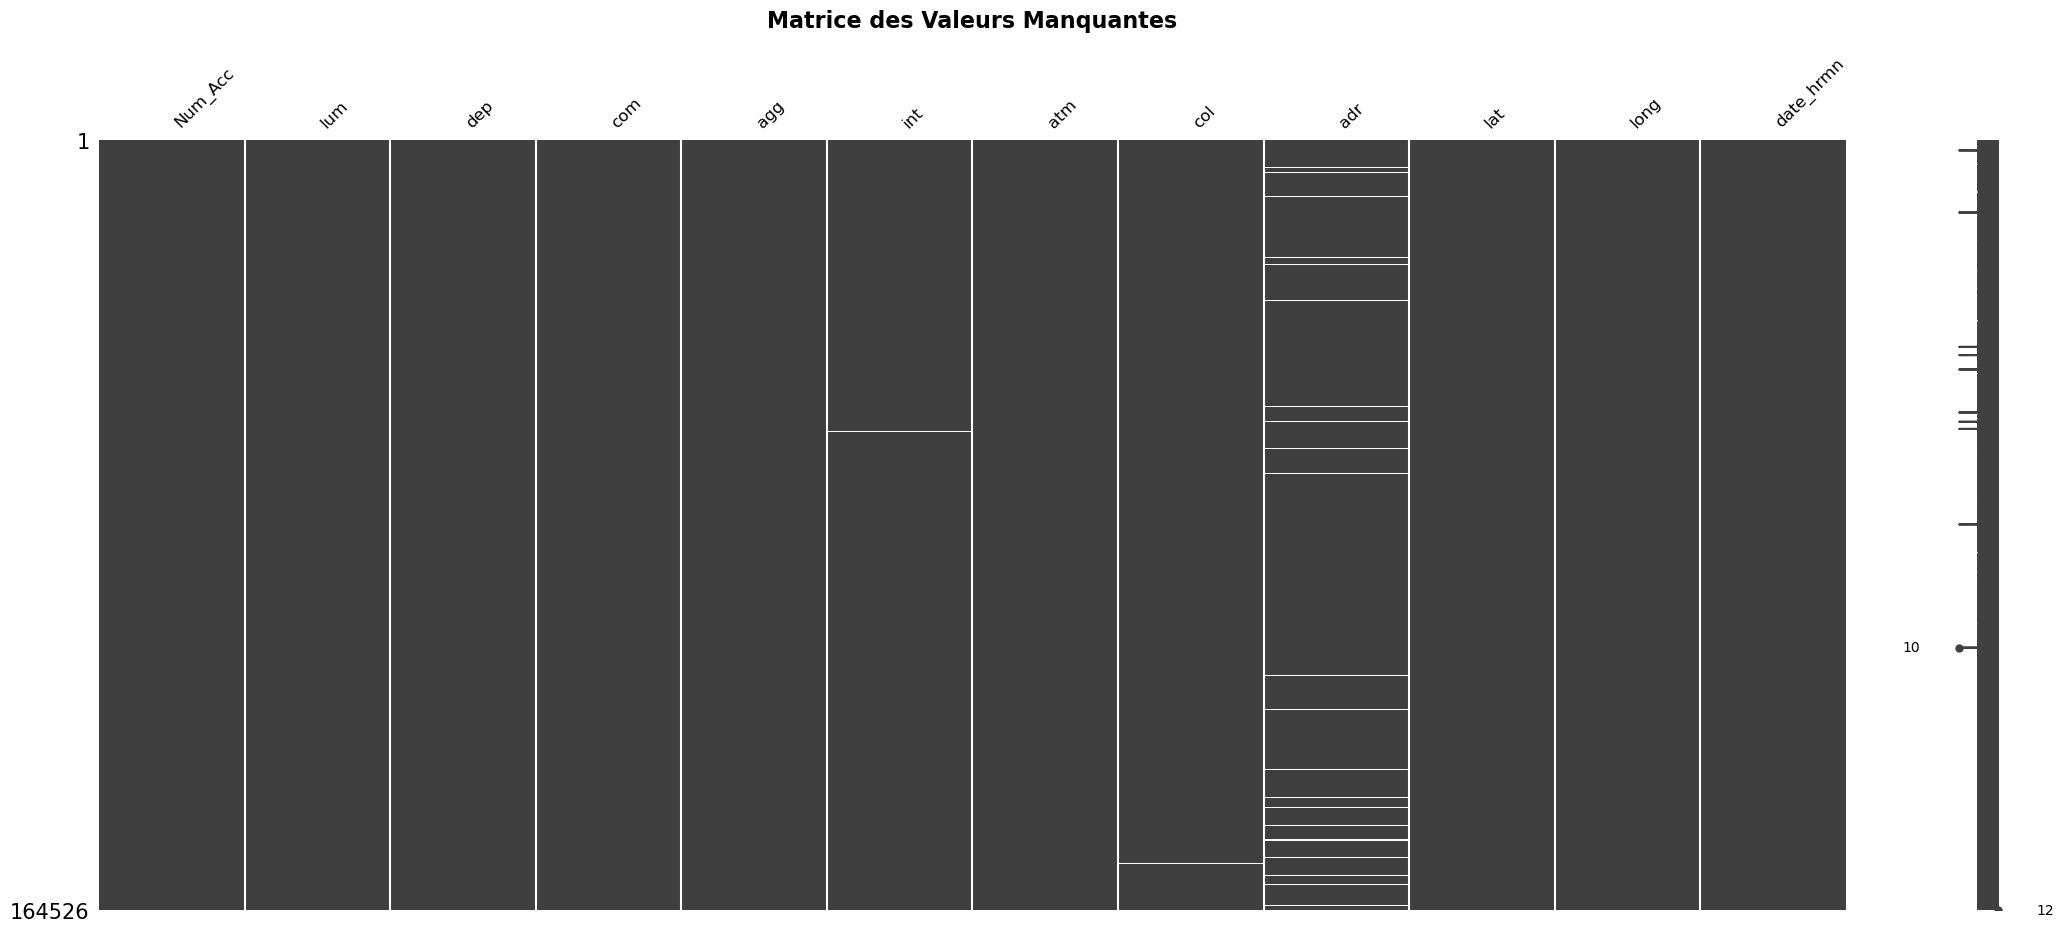

In [39]:
plt.figure(figsize=(14, 8))
msno.matrix(df_caract_cleaning, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Table `LIEUX`

In [40]:
df_lieux_cleaning

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50
1,202200000002,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1,1,0,1,50
2,202200000003,3,ROND POINT DE BREZILLET,0,NaN,-1,2,0,1,0,0,1,NaN,-1,1,5,1,50
3,202200000004,4,QUATORZE JUILLET (RUE DU),0,NaN,1,1,0,2,(1),(1),1,NaN,4,1,0,1,30
4,202200000005,3,ROUTE DE JEAN MOULIN-RN 538,0,NaN,2,2,0,1,8,0,1,NaN,-1,1,0,1,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
196406,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
196407,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
196408,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


On va d'abord nettoyer en string, car dans LIEUX, on a vu dans l’exploration :
- -1 parfois écrit " -1" (avec espaces)
- des valeurs comme "(1)" dans pr/pr1
- des virgules décimales dans larrout (ex "10,5")
- #VALEURMULTI

Donc on commence par uniformiser en string, enlever les espaces, puis convertir en numérique.

In [41]:
# Tout passer en string + nettoyer espaces
for col in df_lieux_cleaning.columns:
    df_lieux_cleaning[col] = (
        df_lieux_cleaning[col]
        .astype("string")
        .str.replace("\xa0", "", regex=False)  # espaces insécables (ex "1 000")
        .str.strip()                           # enlève espaces autour (ex " -1")
    )

In [42]:
# Remplacer les faux manquants "<NA>" (string) par de vrais NA pour la col "voie"
text_cols = ["voie"]  
for col in text_cols:
    if col in df_lieux_cleaning.columns:
        df_lieux_cleaning[col] = df_lieux_cleaning[col].replace({"<NA>": pd.NA, "": pd.NA})

Certaines colonnes sont difficiles à exploiter proprement à ce stade :
- `pr` et `pr1` contiennent des formats mixtes ((1), -1, nombres) et demanderaient un traitement spécifique.
- `v1` et `v2` décrivent des références de voie dans des formats hétérogènes.
- `lartpc` est quasi vide.

Pour éviter de faire des choix au hasard, on les retire pour l’instant.
Elles pourront être réintroduites plus tard si on décide de faire un nettoyage plus avancé.

In [43]:
# Décision : colonnes exclues car trop ambiguës ou pas assez propres
df_lieux_cleaning = df_lieux_cleaning.drop(columns=["v1", "v2", "pr", "pr1", "lartpc"])

In [44]:
# Colonnes à convertir en numérique
cols_lieux_num = [
    "catr", "circ", "nbv", "vosp", "prof", "plan", "larrout", "surf", "infra", "situ", "vma"
]

In [45]:
# Pré-nettoyage puis conversion
for col in cols_lieux_num:
    df_lieux_cleaning[col] = (
        df_lieux_cleaning[col]
        .str.replace(",", ".", regex=False)             # ex 10,5 -> 10.5
        .replace({"-1": pd.NA, "": pd.NA, "<NA>": pd.NA, "#VALEURMULTI": pd.NA})
    )
    df_lieux_cleaning[col] = pd.to_numeric(df_lieux_cleaning[col], errors="coerce")

In [46]:
df_lieux_cleaning.dtypes

Num_Acc     string
catr         Int64
voie        string
circ         Int64
nbv          Int64
vosp         Int64
prof         Int64
plan         Int64
larrout    Float64
surf         Int64
infra        Int64
situ         Int64
vma          Int64
dtype: object

In [47]:
df_lieux_cleaning.head()

,Num_Acc,catr,voie,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma
0,202200000001,4,TEIL(vieille route du),2,2,0,1,1,<NA>,1,0,1,50
1,202200000002,4,<NA>,2,2,0,1,1,<NA>,1,0,1,50
2,202200000003,3,ROND POINT DE BREZILLET,<NA>,2,0,1,1,<NA>,1,5,1,50
3,202200000004,4,QUATORZE JUILLET (RUE DU),1,1,0,2,1,4.0,1,0,1,30
4,202200000005,3,ROUTE DE JEAN MOULIN-RN 538,2,2,0,1,1,<NA>,1,0,1,80


#### Gestion des valeurs manquantes

In [48]:
# %age de valeurs manquantes
missing_percent_lieux = df_lieux_cleaning.isna().mean() * 100
print("\nPourcentage de valeurs manquantes par colonne :")
print(missing_percent_lieux.sort_values(ascending=False))


Pourcentage de valeurs manquantes par colonne :
larrout    77.738404
voie       15.723741
circ        6.382058
vma         4.635711
nbv         4.580724
vosp        4.047655
infra       1.236699
prof        0.136449
surf        0.129830
situ        0.123721
plan        0.105392
catr        0.000000
Num_Acc     0.000000
dtype: float64


C:\Users\cracm\AppData\Local\Temp\ipykernel_15668\131372119.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

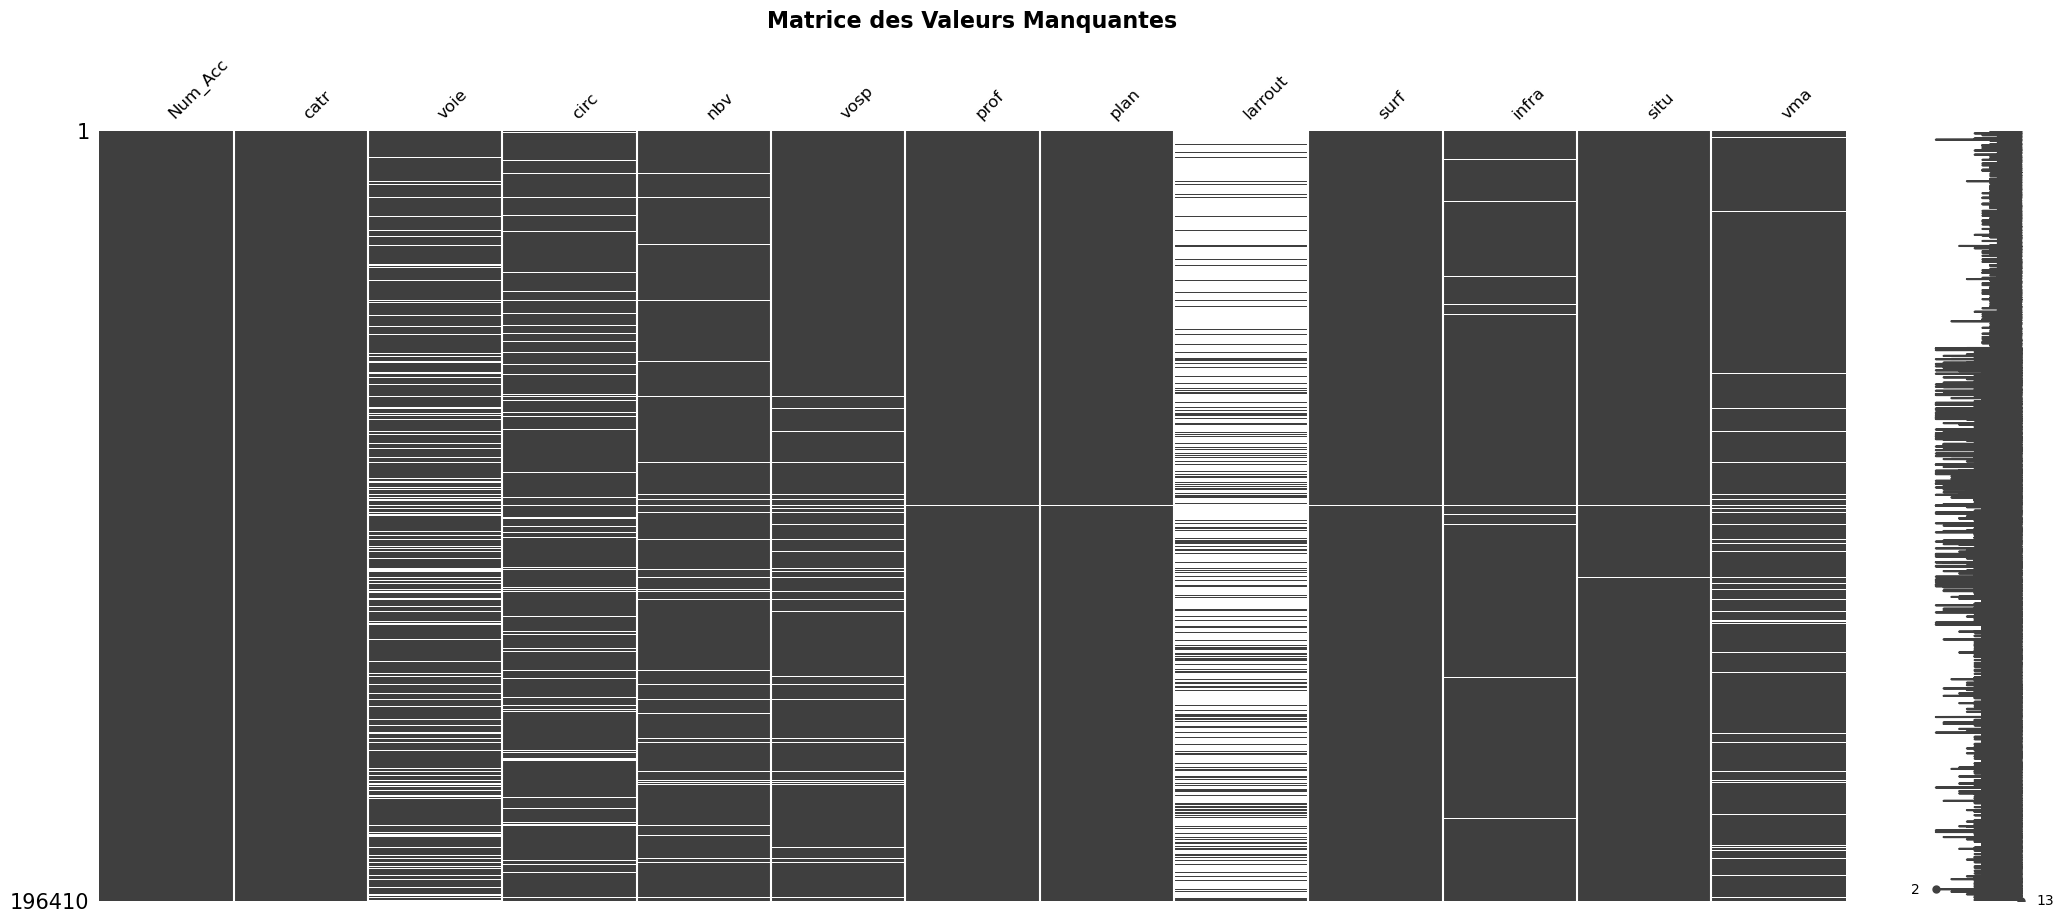

In [49]:
plt.figure(figsize=(14, 8))
msno.matrix(df_lieux_cleaning, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

`larrout` a 77% de valeurs manquantes.  
Une variable aussi incomplète apporte rarement de l’information et complique le traitement (imputation, biais).
On la supprime donc pour garder un dataset plus fiable et plus simple.

In [50]:
df_lieux_cleaning = df_lieux_cleaning.drop(columns=["larrout"])

### Table `USAGERS`

In [51]:
df_usagers_cleaning

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202200000001,1 099 700,813 952,A01,1,1,3,1,2008,5,2,8,-1,-1,-1,-1
1,202200000001,1 099 701,813 953,B01,1,1,1,1,1948,5,1,8,-1,-1,-1,-1
2,202200000002,1 099 698,813 950,B01,1,1,4,1,1988,9,1,0,-1,0,0,-1
3,202200000002,1 099 699,813 951,A01,1,1,1,1,1970,4,1,0,-1,0,0,-1
4,202200000003,1 099 696,813 948,A01,1,1,1,1,2002,0,1,0,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202400054401,203 859 570,155 686 119,Y01,1,1,4,2,1978,0,0,0,0,-1,-1,-1
377634,202400054401,203 859 572,155 686 120,A01,1,1,1,1,1984,0,2,6,0,-1,-1,-1
377635,202400054402,203 859 569,155 686 118,A01,1,1,4,1,1981,4,1,0,-1,-1,-1,-1
377636,202400054402,203 859 571,155 686 121,B01,1,1,4,2,1986,9,1,0,-1,-1,-1,-1


#### Conversion des types de données

In [52]:
for col in ["id_usager", "id_vehicule"]:
    df_usagers_cleaning[col] = (
        df_usagers_cleaning[col]
        .astype("string")
        .str.replace("\xa0", "", regex=False)
        .str.replace(" ", "", regex=False)
    )

In [53]:
cols_usagers_num = [
    "place","catu","grav","sexe","an_nais",
    "trajet","secu1","secu2","secu3","locp","etatp"
]

In [54]:
for col in cols_usagers_num:
    df_usagers_cleaning[col] = pd.to_numeric(df_usagers_cleaning[col], errors="coerce")

In [55]:
# Gestion des -1 : remplacer par NA
missing_cols_usagers = [
    "trajet", "secu1", "secu2", "secu3", "locp", "etatp", "sexe", "place", "grav"
]

In [56]:
for col in missing_cols_usagers:
    df_usagers_cleaning[col] = df_usagers_cleaning[col].replace(-1, pd.NA)

In [57]:
# actp n'est pas utilisée pour construire la cible et n'est pas très propre -> on la retire pour éviter confusion
df_usagers_cleaning = df_usagers_cleaning.drop(columns=["actp"])

In [58]:
df_usagers_cleaning.dtypes

Num_Acc            str
id_usager       string
id_vehicule     string
num_veh            str
place           object
catu             int64
grav            object
sexe            object
an_nais        float64
trajet          object
secu1           object
secu2           object
secu3           object
locp            object
etatp           object
dtype: object

In [59]:
df_usagers_cleaning.head()

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,etatp
0,202200000001,1099700,813952,A01,1,1,3,1,2008.0,5,2,8,<NA>,<NA>,<NA>
1,202200000001,1099701,813953,B01,1,1,1,1,1948.0,5,1,8,<NA>,<NA>,<NA>
2,202200000002,1099698,813950,B01,1,1,4,1,1988.0,9,1,0,<NA>,0,<NA>
3,202200000002,1099699,813951,A01,1,1,1,1,1970.0,4,1,0,<NA>,0,<NA>
4,202200000003,1099696,813948,A01,1,1,1,1,2002.0,0,1,0,<NA>,<NA>,<NA>


#### Pourquoi les variables de la table `USAGERS` ne sont pas utilisées comme features

La table `USAGERS` contient des informations décrivant les personnes impliquées dans l’accident. Ces informations sont :

- hétérogènes (nombre variable d’usagers par accident)
- souvent inconnues au moment de l’accident
- fréquemment conséquences de la gravité et non causes

Afin :
- d’éviter toute fuite de cible
- de garantir un modèle réaliste
- de rester cohérent avec l’unité d’observation (1 ligne = 1 accident)

la table `USAGERS` est utilisée uniquement pour construire la variable cible, mais pas comme source de variables explicatives dans ce travail.

#### Ordonner la gravité puis agréger au niveau accident

La variable `grav` n’est pas ordonnée naturellement. Pour avoir une cible ordonnée :
- 0 = indemne (grav=1)
- 1 = blessé léger (grav=4)
- 2 = blessé hospitalisé (grav=3)
- 3 = tué (grav=2)

Or, pour la modélisation, il est important que les valeurs numériques respectent un ordre logique de gravité.

In [60]:
grav_map = {1: 0, 4: 1, 3: 2, 2: 3}

In [61]:
df_usagers_cleaning["grav_ord"] = df_usagers_cleaning["grav"].map(grav_map)

**Vérification de la transformation `grav → grav_ord`**

Avant d’aller plus loin, on vérifie que :
- toutes les modalités de `grav` sont bien présentes
- la transformation vers `grav_ord` a bien fonctionné
- la classe `0` (indemne) est bien représentée

On compare donc les distributions de `grav` et `grav_ord`.

In [62]:
df_usagers_cleaning["grav"].value_counts(dropna=False) # dropna=False pour que les NaN soient comptés

grav
1       159949
4       149293
3        57657
2        10380
<NA>       359
Name: count, dtype: int64

In [63]:
# Vérifier que grav_ord contient bien 0
df_usagers_cleaning["grav_ord"].value_counts(dropna=False)

grav_ord
0.0    159949
1.0    149293
2.0     57657
3.0     10380
NaN       359
Name: count, dtype: int64

**Vérifier la gravité maximale par accident**

Un accident peut impliquer plusieurs usagers, donc plusieurs lignes dans la table `USAGERS`.

Pour anticiper l’agrégation au niveau accident, on calcule pour chaque `Num_Acc`, la gravité maximale (`max`) parmi les usagers.

Cela permet de :
- vérifier la distribution réelle des accidents selon leur gravité
- identifier s’il existe des accidents avec uniquement des usagers indemnes

In [64]:
tmp = df_usagers_cleaning.groupby("Num_Acc")["grav_ord"].max()

In [65]:
tmp.value_counts(dropna=False) 

grav_ord
1.0    105172
2.0     49588
3.0      9766
Name: count, dtype: int64

**Interprétation : absence d’accidents "indemne uniquement"**

En observant la gravité maximale par accident (`grav_ord.max()`), on constate que :
- aucune valeur maximale n’est égale à `0`
- donc aucun accident n’a uniquement des usagers indemnes

Ce résultat est cohérent avec la définition même de la base BAAC :
> un accident corporel implique au moins une victime (blessée ou tuée)

La modalité `0 = indemne` existe au niveau usager, mais jamais comme gravité maximale au niveau accident.

In [66]:
# Combien d'accidents ont uniquement des indemnes ?
nb_only_indemne = (tmp == 0).sum()
nb_total = tmp.shape[0]
print("Accidents 'indemne uniquement' (max grav_ord = 0) :", nb_only_indemne, "/", nb_total)

Accidents 'indemne uniquement' (max grav_ord = 0) : 0 / 164526


**Conclusion**
- pour chaque accident, le max de `grav_ord` n’est jamais 0
- donc aucun accident n’a “uniquement des indemnes”

#### Aligner avec l'unité d'observation  

L’objectif final est de construire un dataset :
- *1 ligne = 1 accident*
- des variables décrivant les circonstances
- une variable cible représentant la gravité globale de l’accident

Or :
- `grav` est définie au niveau usager
- un accident peut avoir plusieurs usagers avec des gravités différentes

Pour aligner la cible avec l’unité accident, on adopte la règle suivante :
> *la gravité d’un accident est définie par la gravité la plus élevée parmi ses usagers*

In [67]:
target_accident = (
    df_usagers_cleaning
    .groupby("Num_Acc", as_index=False)["grav_ord"]
    .max()
    .rename(columns={"grav_ord": "target_grav"})
)

In [68]:
target_accident["target_grav"] = target_accident["target_grav"].astype("Int64")

In [69]:
target_accident["target_grav"].value_counts(dropna=False) 

target_grav
1    105172
2     49588
3      9766
Name: count, dtype: Int64

**Création de la variable cible finale (`target_grav`)**

On agrège la table `USAGERS` au niveau accident en conservant :
- `Num_Acc`
- la gravité maximale ordonnée (`target_grav`)

On ajoute ensuite une version textuelle (`target_grav_label`) pour :
- faciliter l’interprétation
- améliorer la lisibilité en EDA

In [70]:
target_label_map = {
    0: "Indemne uniquement",
    1: "Blessé léger",
    2: "Blessé hospitalisé",
    3: "Tué"
}

In [71]:
target_accident["target_grav_label"] = target_accident["target_grav"].map(target_label_map)

In [72]:
target_accident.head()

,Num_Acc,target_grav,target_grav_label
0,202200000001,2,Blessé hospitalisé
1,202200000002,1,Blessé léger
2,202200000003,1,Blessé léger
3,202200000004,1,Blessé léger
4,202200000005,1,Blessé léger


**Vérification finale de la variable cible**

Avant de poursuivre :
- on vérifie la distribution de `target_grav`
- on s’assure qu’il n’y a pas de valeurs manquantes
- on valide que chaque accident possède bien une gravité définie

Cette étape permet de garantir que la variable cible est :
- complète
- cohérente
- prête pour l’EDA et la modélisation

In [73]:
missing_percent_target = target_accident.isna().mean() * 100
missing_percent_target

Num_Acc              0.0
target_grav          0.0
target_grav_label    0.0
dtype: float64

**Vérification de cohérence**

1 accident = 1 ligne

In [74]:
target_accident["Num_Acc"].is_unique, target_accident.shape

(True, (164526, 3))

## Réduction de la table `LIEUX` à 1 ligne = 1 accident

La table `LIEUX` peut contenir plusieurs lignes pour un même accident (par exemple si plusieurs voies ou segments sont renseignés).  
Comme l’objectif final est de construire un dataset au niveau accident (1 accident = 1 ligne), nous devons ramener `LIEUX` à une seule observation par `Num_Acc` afin de pouvoir fusionner proprement avec `CARACTERISTIQUES` (qui est déjà unique par accident).

Avant cela, on va vérifier si les accidents qui ont le même `Num_Acc` ont bien tous lieu au même endroit.

In [77]:
# Vérifier combien de lignes décrivent un même accident : identifier si certains accidents sont décrits sur plusieurs lignes
df_lieux.groupby("Num_Acc").size().value_counts()

1    133011
2     31178
3       307
4        28
5         2
Name: count, dtype: int64

- La majorité des accidents ont 1 seule ligne
- Un nombre non négligeable ont 2 lignes
- Très peu ont plus de 3 lignes

In [78]:
# Vérifier si un accident est associé à une seule voie ou plusieurs : compte le nombre de valeurs distinctes de 'voie' par Num_Acc
voie_par_accident = (
    df_lieux
    .groupby("Num_Acc")["voie"]
    .nunique(dropna=False)
)

In [79]:
voie_par_accident.value_counts().head()

voie
1    136293
2     27979
3       229
4        23
5         2
Name: count, dtype: int64

- Environ 28 000 accidents ont plus d’une voie
- Ce n’est pas marginal
- Donc l’hypothèse “une seule voie par accident” est fausse

In [80]:
# Identifier les accidents associés à plusieurs voies
accidents_voies_multiples = voie_par_accident[voie_par_accident > 1]

In [82]:
accidents_voies_multiples

Num_Acc
202300000001    2
202300000003    2
202300000008    2
202300000009    2
202300000016    2
               ..
202400054386    2
202400054387    2
202400054388    2
202400054393    2
202400054398    2
Name: voie, Length: 28233, dtype: int64

In [83]:
# Inspection d'un accident multi-voies pour comprendre si les voies correspondent à une intersection réelle
df_lieux[df_lieux["Num_Acc"] == accidents_voies_multiples.index[0]]

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
55302,202300000001,4,RUE DE RIVOLI,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
55303,202300000001,4,RUE SAINT FLORENTIN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30


- L’accident se produit à une intersection
- Il est donc logiquement associé à plusieurs voies
- Ce n’est pas une incohérence de données

In [84]:
# Vérifier la cohérence du lieu à partir de plusieurs variables descriptives
cols_lieu = ["voie", "v1", "v2", "pr", "pr1"]

In [85]:
lieu_par_accident = (
    df_lieux
    .groupby("Num_Acc")[cols_lieu]
    .nunique(dropna=False)
)

In [86]:
lieu_par_accident.head()

,voie,v1,v2,pr,pr1
Num_Acc,,,,,
202200000001,1,1,1,1,1
202200000002,1,1,1,1,1
202200000003,1,1,1,1,1
202200000004,1,1,1,1,1
202200000005,1,1,1,1,1


In [87]:
lieu_par_accident.max()

voie    5
v1      2
v2      2
pr      3
pr1     3
dtype: int64

- Certaines variables varient légèrement
- Mais aucune explosion de valeurs
- Les variations sont compatibles avec un même lieu réel (intersection, changement de repère routier)

**Conclusion**  

Hypothèse partiellement infirmée, mais méthodologiquement validée 
- Faux : un accident correspond toujours à une seule voie
- Vrai : les lignes multiples décrivent le même lieu physique (intersection, carrefour, giratoire, etc.)

La table `LIEUX` peut contenir plusieurs lignes pour un même accident (`Num_Acc`). Nous avons vérifié si ces lignes correspondaient à des lieux différents ou à une représentation détaillée d’un même lieu.

Les analyses montrent que :
- certains accidents sont associés à plusieurs voies (`voie`)
- ces cas correspondent principalement à des intersections, carrefours ou giratoires
- les autres variables descriptives du lieu (`v1`, `v2`, `pr`, `pr1`) restent cohérentes

Ainsi, les lignes multiples décrivent un *même lieu physique*, avec des points de vue
différents (axes routiers concernés).

Nous pouvons donc agréger la table `LIEUX` à *une ligne par accident*, sans perte d’information critique.

### Agrégation de la table `LIEUX` par résumé statistique (1 accident = 1 ligne)

La table `LIEUX` peut contenir plusieurs lignes pour un même accident (ex : accident à une intersection, voies multiples, segments distincts).
Or, notre dataset final doit être au niveau accident (**1 ligne = 1 accident**).  

Plutôt que de garder arbitrairement une seule ligne (ex : la première), on utilise une agrégation qui résume l'information disponible pour chaque accident :

- Pour les variables numériques (ex : nombre de voies, vitesse max), on prend un résumé robuste (`max` ou `median` selon le sens).
- Pour les variables catégorielles (ex : catégorie de route, état de la surface), on prend la modalité la plus fréquente (`mode`).
- On ajoute aussi des variables de "complexité" qui décrivent si l’accident concerne plusieurs lignes/voies dans `LIEUX` (utile pour comprendre et potentiellement améliorer le modèle).

Objectif : conserver davantage d’information tout en gardant une table finale cohérente pour le machine learning.

In [88]:
def safe_mode(s: pd.Series):
    """
    Retourne la modalité la plus fréquente (mode).
    Si la série est vide ou ne contient que des NA, renvoie pd.NA.
    En cas d'égalité, pandas.mode() renvoie plusieurs valeurs : on prend la première.
    """
    s = s.dropna()
    if s.empty:
        return pd.NA
    return s.mode().iloc[0]

In [89]:
# Features décrivant la "complexité" de LIEUX pour un accident
lieux_complexite = (
    df_lieux_cleaning
    .groupby("Num_Acc")
    .agg(
        nb_lignes_lieux=("Num_Acc", "size"),                 # combien de lignes LIEUX pour l'accident
        nb_voies_uniques=("voie", lambda x: x.nunique(dropna=True))  # combien de voies distinctes (hors NA)
    )
    .reset_index()
)

In [90]:
lieux_complexite.head()

,Num_Acc,nb_lignes_lieux,nb_voies_uniques
0,202200000001,1,1
1,202200000002,1,0
2,202200000003,1,1
3,202200000004,1,1
4,202200000005,1,1


In [91]:
df_lieux_cleaning.columns

Index(['Num_Acc', 'catr', 'voie', 'circ', 'nbv', 'vosp', 'prof', 'plan',
       'surf', 'infra', 'situ', 'vma'],
      dtype='str')

In [92]:
# Agrégation de LIEUX : 1 ligne = 1 accident
df_lieux_agg = (
    df_lieux_cleaning
    .groupby("Num_Acc", as_index=False)
    .agg(
        # Variables "catégorielles codées" : on prend la modalité la plus fréquente
        catr=("catr", safe_mode),
        circ=("circ", safe_mode),
        vosp=("vosp", safe_mode),
        prof=("prof", safe_mode),
        plan=("plan", safe_mode),
        surf=("surf", safe_mode),
        infra=("infra", safe_mode),
        situ=("situ", safe_mode),

        # Variables "numériques" : on prend un résumé
        nbv=("nbv", "max"),          # nb total de voies : max = on garde le cas le plus large
        vma=("vma", "max"),          # vitesse max : max = version "pire cas" / plus rapide
    )
)

In [93]:
df_lieux_agg.head()

,Num_Acc,catr,circ,vosp,prof,plan,surf,infra,situ,nbv,vma
0,202200000001,4,2,0,1,1,1,0,1,2,50
1,202200000002,4,2,0,1,1,1,0,1,2,50
2,202200000003,3,<NA>,0,1,1,1,5,1,2,50
3,202200000004,4,1,0,2,1,1,0,1,1,30
4,202200000005,3,2,0,1,1,1,0,1,2,80


In [94]:
# On ajoute les variables de complexité (nb de lignes / nb de voies distinctes)
df_lieux_acc = (
    df_lieux_agg
    .merge(lieux_complexite, on="Num_Acc", how="left")
)

In [95]:
df_lieux_acc.head()

,Num_Acc,catr,circ,vosp,prof,plan,surf,infra,situ,nbv,vma,nb_lignes_lieux,nb_voies_uniques
0,202200000001,4,2,0,1,1,1,0,1,2,50,1,1
1,202200000002,4,2,0,1,1,1,0,1,2,50,1,0
2,202200000003,3,<NA>,0,1,1,1,5,1,2,50,1,1
3,202200000004,4,1,0,2,1,1,0,1,1,30,1,1
4,202200000005,3,2,0,1,1,1,0,1,2,80,1,1


### Vérifications après agrégation

Après agrégation, on vérifie deux points importants :

1. Unicité : chaque `Num_Acc` doit apparaître une seule fois (sinon la fusion avec `CARACTERISTIQUES` dupliquera des accidents).
2. Cohérence : on contrôle la distribution de `nb_lignes_lieux` et `nb_voies_uniques` pour comprendre combien d'accidents étaient multi-lignes / multi-voies dans la table `LIEUX`.

Ces vérifications permettent de s'assurer que la table `LIEUX` est bien alignée avec l'unité d'observation "accident".

In [96]:
# 1. Unicité
print("Num_Acc unique dans df_lieux_acc ?", df_lieux_acc["Num_Acc"].is_unique)
print("Shape df_lieux_acc:", df_lieux_acc.shape)

Num_Acc unique dans df_lieux_acc ? True
Shape df_lieux_acc: (164526, 13)


In [97]:
# 2. Distribution des accidents multi-lignes / multi-voies
df_lieux_acc["nb_lignes_lieux"].value_counts().head(10), df_lieux_acc["nb_voies_uniques"].value_counts().head(10)

(nb_lignes_lieux
 1    133011
 2     31178
 3       307
 4        28
 5         2
 Name: count, dtype: int64,
 nb_voies_uniques
 1    131927
 0     16242
 2     16142
 3       191
 4        22
 5         2
 Name: count, dtype: int64)

### Conclusion sur l’agrégation de la table `LIEUX`

Les vérifications confirment que l’agrégation de la table `LIEUX` est correcte et cohérente avec l’objectif du projet :

- Chaque accident (`Num_Acc`) apparaît *une seule fois* dans `df_lieux_acc`, ce qui garantit une unité d’observation claire : *1 ligne = 1 accident*.
- Le nombre total de lignes est identique à celui des tables `CARACTERISTIQUES` et de la cible (`164 526` accidents), ce qui permettra une fusion sans duplication.

L’analyse des variables de complexité montre que :
- La majorité des accidents n’ont qu’une seule ligne dans la table `LIEUX`, mais une part non négligeable concerne plusieurs lignes (accidents à des intersections, sur plusieurs voies, etc.).
- De même, la plupart des accidents sont associés à une seule voie, mais certains impliquent plusieurs voies distinctes.

La stratégie d’agrégation par résumé statistique (modalité la plus fréquente pour les variables catégorielles, valeur maximale pour certaines variables numériques) permet donc :
- de conserver l’information essentielle au niveau accident,
- d’éviter un choix arbitraire d’une ligne parmi plusieurs,
- tout en restant compatible avec les étapes suivantes d’EDA et de modélisation.

Le dataset `df_lieux_acc` est désormais prêt à être fusionné avec les autres tables pour constituer le dataset final d’analyse.

## Renommer les colonnes pour que ce soit plus compréhensible

In [98]:
df_caract_cleaning = df_caract_cleaning.rename(columns={
    "lum": "luminosite", 
    "agg": "acc_est_en_agglo", 
    "int": "intersection", 
    "atm": "cond_atmo",
    "col": "type_collision"
})

In [99]:
df_lieux_acc = df_lieux_acc.rename(columns={
    "catr": "categ_route", 
    "circ": "regime_circu",
    "nbv": "nbre_voies_circu",
    "vosp": "voie_reserve",
    "prof": "declivite_route",
    "plan": "courbe_droit",
    "surf": "etat_surface",
    "infra": "amenagement_infra",
    "situ": "situation_voie_acc",
    "vma": "vitesse_max_auto"
})

## Fusion finale

Choix des jointures lors de la fusion
- Jointure inner entre `CARACTERISTIQUES` et la cible : on ne garde que les accidents pour lesquels on connaît la gravité (cible indispensable).
- Jointure left avec `LIEUX` : on garde tous les accidents et on ajoute les infos de lieu quand elles existent, sans supprimer d’accidents si `LIEUX` est incomplet.

In [100]:
df_final = (
    df_caract_cleaning
    .merge(
        target_accident[["Num_Acc", "target_grav"]],
        on="Num_Acc",
        how="inner"
    )
    .merge(
        df_lieux_acc,
        on="Num_Acc",
        how="left"
    )
)

In [101]:
df_final

,Num_Acc,luminosite,dep,com,acc_est_en_agglo,intersection,cond_atmo,type_collision,adr,lat,...,voie_reserve,declivite_route,courbe_droit,etat_surface,amenagement_infra,situation_voie_acc,nbre_voies_circu,vitesse_max_auto,nb_lignes_lieux,nb_voies_uniques
0,202200000001,1,26,26198,True,3,1,3,TEIL(vieille route du),44.55942,...,0,1,1,1,0,1,2,50,1,1
1,202200000002,1,25,25204,True,3,1,3,Miranda,46.92581,...,0,1,1,1,0,1,2,50,1,0
2,202200000003,1,22,22360,True,6,1,2,ROND POINT DE BREZILLET,48.493162,...,0,1,1,1,5,1,2,50,1,1
3,202200000004,1,16,16102,True,3,8,6,LOHMEYER (RUE),45.692652,...,0,2,1,1,0,1,1,30,1,1
4,202200000005,1,13,13103,False,1,1,2,ROUTE DE JEAN MOULIN-RN 538,43.675579,...,0,1,1,1,0,1,2,80,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202400054398,5,94,94065,True,3,2,6,Avenue Charles Lindbergh,48.7574,...,0,1,1,2,5,4,3,50,2,1
164522,202400054399,1,92,92062,True,1,1,6,RUE PIERRE GAUDIN,48.886943,...,2,1,2,1,0,1,1,30,1,1
164523,202400054400,3,29,29068,False,1,1,1,PK 031.950 RN12,48.52619,...,0,2,1,1,0,1,2,110,1,1
164524,202400054401,1,92,92012,True,1,1,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,48.832862,...,0,1,1,1,0,1,3,50,1,1


**Dataset final prêt pour l’EDA**

À ce stade :
- 1 ligne = 1 accident
- aucune valeur manquante sur la variable cible
- variables explicatives = contexte (temps, lieu, infrastructure)
- pas de fuite de cible identifiée

Le dataset est prêt pour l’analyse exploratoire (EDA) et la modélisation.

### Vérification après fusion

In [102]:
df_final.shape

(164526, 25)

In [103]:
df_final["Num_Acc"].is_unique

True

In [104]:
df_final.dtypes

Num_Acc                       object
luminosite                     Int64
dep                           string
com                           string
acc_est_en_agglo             boolean
intersection                   Int64
cond_atmo                      Int64
type_collision                 Int64
adr                           string
lat                          Float64
long                         Float64
date_hrmn             datetime64[us]
target_grav                    Int64
categ_route                    Int64
regime_circu                   Int64
voie_reserve                   Int64
declivite_route                Int64
courbe_droit                   Int64
etat_surface                   Int64
amenagement_infra              Int64
situation_voie_acc             Int64
nbre_voies_circu               Int64
vitesse_max_auto               Int64
nb_lignes_lieux                int64
nb_voies_uniques               int64
dtype: object

In [105]:
# Vérifier qu'on n'a pas perdu d'accidents
df_caract_cleaning.shape[0] == df_final.shape[0]

True

In [106]:
df_final["target_grav"].isna().mean()

np.float64(0.0)

On obtient `df_final` : un dataset au niveau accident (1 ligne = 1 accident), avec :
- des variables de contexte (date/heure, environnement, route…)
- une variable cible `target_grav` (gravité globale de l’accident)

Ce dataset servira pour l’EDA puis le feature engineering.

### Export des données nettoyées

Le dataset final est exporté pour être utilisé dans les notebooks d’EDA et de modélisation.

In [107]:
df_final.to_csv("../data/processed/accidents_clean_eda.csv", index=False)